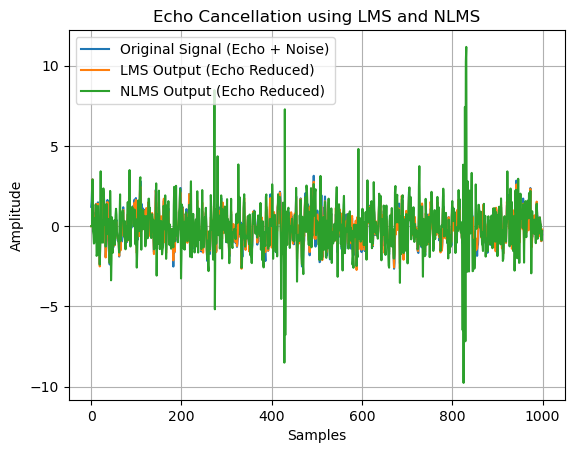

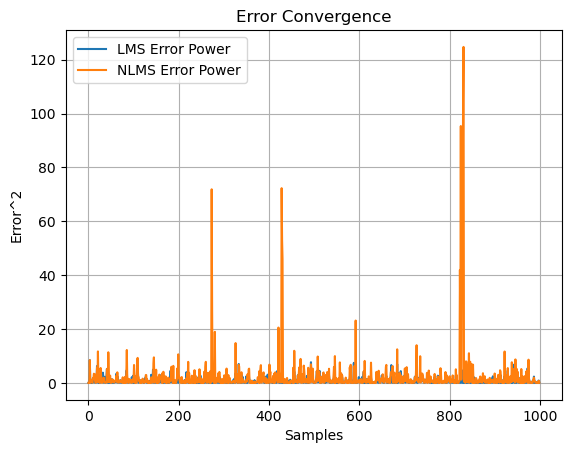

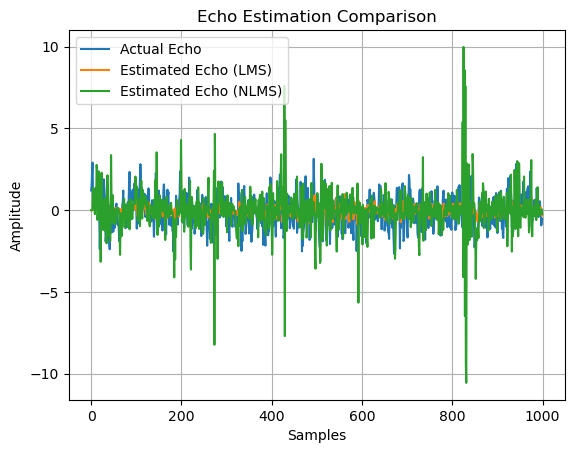

Echo Cancellation Completed!
LMS and NLMS successfully reduced echo from the signal.


In [1]:
# =========================================================
# Adaptive Echo Cancellation using LMS and NLMS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Generate Signals (Echo Simulation)
# =========================================================

np.random.seed(0)
N = 1000

# Input signal (far-end)
x = np.random.randn(N)

# Unknown echo path
h = np.array([0.8, 0.5, 0.3])

# Generate echo
echo = np.convolve(x, h, mode='same')

# Add small noise (near-end)
noise = 0.01 * np.random.randn(N)

# Microphone signal (echo + noise)
d = echo + noise

# =========================================================
# 2. LMS Algorithm
# =========================================================

def lms(x, d, mu, filter_order):
    N = len(x)
    w = np.zeros(filter_order)
    y = np.zeros(N)
    e = np.zeros(N)

    for n in range(filter_order, N):
        x_vec = x[n-filter_order:n][::-1]   # input vector
        
        y[n] = np.dot(w, x_vec)            # estimated echo
        e[n] = d[n] - y[n]                 # error (cleaned signal)
        
        w = w + mu * x_vec * e[n]          # weight update

    return y, e

# =========================================================
# 3. NLMS Algorithm
# =========================================================

def nlms(x, d, mu, filter_order, epsilon=1e-6):
    N = len(x)
    w = np.zeros(filter_order)
    y = np.zeros(N)
    e = np.zeros(N)

    for n in range(filter_order, N):
        x_vec = x[n-filter_order:n][::-1]
        
        y[n] = np.dot(w, x_vec)
        e[n] = d[n] - y[n]
        
        norm = np.dot(x_vec, x_vec) + epsilon
        w = w + (mu / norm) * x_vec * e[n]

    return y, e

# =========================================================
# 4. Run Algorithms
# =========================================================

filter_order = 3
mu_lms = 0.01
mu_nlms = 0.5

y_lms, e_lms = lms(x, d, mu_lms, filter_order)
y_nlms, e_nlms = nlms(x, d, mu_nlms, filter_order)

# =========================================================
# 5. Plot Results (Echo Cancellation)
# =========================================================

plt.figure()
plt.plot(d, label="Original Signal (Echo + Noise)")
plt.plot(e_lms, label="LMS Output (Echo Reduced)")
plt.plot(e_nlms, label="NLMS Output (Echo Reduced)")
plt.title("Echo Cancellation using LMS and NLMS")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# 6. Error Convergence Plot
# =========================================================

plt.figure()
plt.plot(e_lms**2, label="LMS Error Power")
plt.plot(e_nlms**2, label="NLMS Error Power")
plt.title("Error Convergence")
plt.xlabel("Samples")
plt.ylabel("Error^2")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# 7. Compare Estimated Echo vs Actual Echo
# =========================================================

plt.figure()
plt.plot(echo, label="Actual Echo")
plt.plot(y_lms, label="Estimated Echo (LMS)")
plt.plot(y_nlms, label="Estimated Echo (NLMS)")
plt.title("Echo Estimation Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# 8. Print Summary
# =========================================================

print("Echo Cancellation Completed!")
print("LMS and NLMS successfully reduced echo from the signal.")